In [2]:
%load_ext autoreload
%autoreload 2

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sys import path
path.append('../../fourier/')
import frequency_estimate as fe

path.append('../../signals/')
import signals as sg


In [254]:
T = 500
fs = 2
nt = int(T*fs)
f0 = 0.015
freqs = np.arange(1,4)*f0
amps = [0.3, 1, 0.7]

t = np.arange(nt)/fs

x = np.array([sg.cosine(T, fi, fs, amplitude=a)[1] for fi, a in zip(freqs, amps)]).mean(axis=0)
x += np.random.randn(x.size)

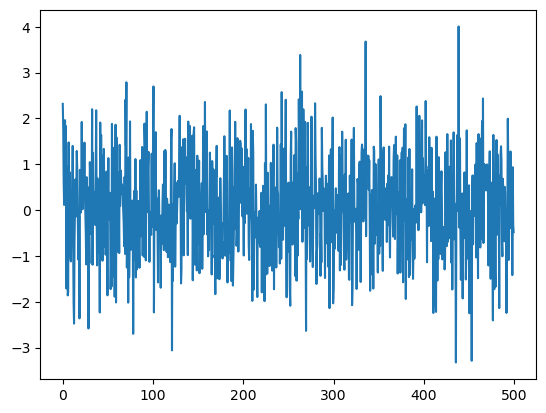

In [256]:
plt.plot(t, x)

In [258]:
freq, p = fe.periodogram(x, fs=fs)

In [260]:
res = fe.detect_periodogram_peaks(freq, p, [0.5, 0.8], [0.01, 0.05])

In [268]:
res['p_global<0.05'] = res.p_global<0.05

In [270]:
res.to_dataframe()

,frequency,power,Z,p_single,p_global,index,signif,p_global<0.05
peak,,,,,,,,
0,0.016,3.926307,3.444121,3.193281e-02,0.494157,8,False,False
1,0.020,1.122921,0.985016,3.734332e-01,0.999946,10,False,False
2,0.026,0.634977,0.556996,5.729276e-01,1.000000,13,False,False
3,0.030,18.998704,16.665495,5.784521e-08,0.000001,15,True,True
4,0.042,2.324486,2.039019,1.301564e-01,0.946511,21,False,False
5,0.046,7.027318,6.164301,2.103188e-03,0.043250,23,True,True


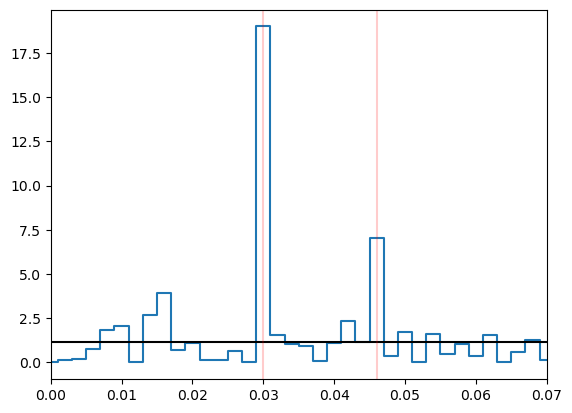

In [272]:
plt.step(freq, p, where='mid')
plt.xlim(0., 0.07)
plt.axhline(res.attrs['P0'], color='k')

for fi in res.frequency[res['p_global<0.05']]:
    plt.axvline(fi, color='r', alpha=0.2)

In [281]:
fe.detect_periodogram_peaks(freq, p, [0.5, 0.8], [0.01, 0.05], p_global_max=0.05)

<xarray.Dataset> Size: 96B
Dimensions:    (peak: 2)
Dimensions without coordinates: peak
Data variables:
    frequency  (peak) float64 16B 0.03 0.046
    power      (peak) float64 16B 19.0 7.027
    Z          (peak) float64 16B 16.67 6.164
    p_single   (peak) float64 16B 5.785e-08 0.002103
    p_global   (peak) float64 16B 1.215e-06 0.04325
    index      (peak) int64 16B 15 23
Attributes:
    P0:           1.1400023936881185
    noise_band:   [0.5, 0.8]
    signal_band:  [0.01, 0.05]
    N_tested:     21